# 04 - Grievance Disposal Analysis

Disposal-time analysis: how long grievances take to dispose, broken down
by year, category/subcategory, office, department, and district.

Shared scaffolding (data load, date parsing, analysis window, district name
fixes, population data, generic helpers) lives in `grievance_common.py`.

## Setup

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from grievance_common import (
    load_complaints, add_time_fields, filter_window, compute_disposal_days,
    population_df, load_district_shapefile, OUTPUT_DIR, FOCUS_YEAR, MAP_YEARS,
    VALID_YEARS,
)

## Data Load and Preparation

Load complaints, parse dates, derive time fields, compute `resolution_days`
(dropping negative values, which are data errors), and apply the analysis
window. `df_res` is the working frame for all resolution statistics.

In [2]:
df = add_time_fields(load_complaints())

# disposal_days = disposed_on - created_on (negative values dropped)
df = compute_disposal_days(df, drop_negative=True)

# analysis window
df_res = filter_window(df)

print(f"{len(df_res):,} rows with valid disposal data in the window.")
df_res[["created_on", "resolved_on", "disposal_days"]].head()

1,323,827 rows with valid disposal data in the window.


,created_on,resolved_on,disposal_days
5,2021-07-23 20:10:39,2021-10-31 15:26:03,99.802361
6,2021-09-09 11:20:57,2021-10-31 15:26:03,52.170208
7,2021-11-01 09:35:18,2022-03-30 18:25:25,149.368137
8,2021-11-09 09:00:34,2023-08-05 15:35:15,634.274086
9,2021-11-15 13:35:06,2021-11-15 15:31:38,0.080926


In [4]:
print("created_on nulls  :", df_res["created_on"].isna().sum())
print("resolved_on nulls :", df_res["resolved_on"].isna().sum())
print("disposal_days nulls:", df_res["disposal_days"].isna().sum())

created_on nulls  : 0
resolved_on nulls : 132479
disposal_days nulls: 132479


In [17]:
# Year-wise descriptive statistics.
yearly_stats = (
    df_res.groupby("custom_year")
          .agg(count=("disposal_days", "count"),
               mean=("disposal_days", "mean"),
               median=("disposal_days", "median"))
          .reset_index()
          .round(0)
)
yearly_stats

,custom_year,count,mean,median
0,2021-2022,96295,195.0,131.0
1,2022-2023,176761,90.0,36.0
2,2023-2024,337164,98.0,51.0
3,2024-2025,581128,58.0,33.0


In [18]:
# Complaint volume per year, with each year's share of the 4-year total.
yearly_count = (
    df_res.groupby("custom_year")
          .agg(count=("ticket_no", "nunique"))
          .reset_index()
)
yearly_count["percentage"] = (
    yearly_count["count"] / yearly_count["count"].sum() * 100
).round(2)
yearly_count

,custom_year,count,percentage
0,2021-2022,98258,7.42
1,2022-2023,181699,13.73
2,2023-2024,355571,26.86
3,2024-2025,688299,51.99


## Overall Disposal Statistics

## Helper Functions

In [19]:
# ----- general ---------------------------------------------------------------
 
def _add_aggregate(df, year_col="custom_year"):
    """Append a copy of df with custom_year set to 'Aggregate'."""
    agg = df.copy()
    agg[year_col] = "Aggregate"
    return pd.concat([df, agg], ignore_index=True)
 
 
def _total_row(df, level_col, value_col="disposal_days"):
    """Single TOTAL summary row (count/mean/median/std) for a stats table."""
    return pd.DataFrame([{
        level_col: "TOTAL",
        "count":   df[value_col].count(),
        "mean":    round(df[value_col].mean(),   2),
        "median":  round(df[value_col].median(), 2),
        "std":     round(df[value_col].std(),    2),
    }])
 
 
def _sort_by_year_order(df, year_col="custom_year"):
    """Sort a yearly stats frame by VALID_YEARS then Aggregate."""
    year_order = VALID_YEARS + ["Aggregate"]
    df["_ord"] = df[year_col].map(
        {y: i for i, y in enumerate(year_order)}).fillna(99)
    return df.sort_values("_ord").drop(columns="_ord")
 
 
# ----- ticket-level ----------------------------------------------------------
 
def disposal_stats_by_level(data, level_col, sort_by="count"):
    """count / mean / median / std disposal days by level_col.
    Appends a TOTAL row. sort_by: 'count' or 'mean'."""
    d = data.copy()
    d[level_col] = d[level_col].fillna("NaN").astype(str).str.strip()
    stats = (
        d.groupby(level_col, dropna=False)
         .agg(count=("disposal_days",  "count"),
              mean=("disposal_days",   "mean"),
              median=("disposal_days", "median"),
              std=("disposal_days",    "std"))
         .reset_index().round(2)
         .sort_values(sort_by, ascending=(sort_by == "mean"))
    )
    return pd.concat([stats, _total_row(data, level_col)], ignore_index=True)
 
 
def level_yearly_pivot(data, level_col):
    """count / mean / median / std by level_col x year (+ Aggregate).
    ORIGINAL function — std and Aggregate year added."""
    d = _add_aggregate(data)
    stats = (
        d.groupby([level_col, "custom_year"], dropna=False)
         .agg(count=("disposal_days",  "count"),
              mean=("disposal_days",   "mean"),
              median=("disposal_days", "median"),
              std=("disposal_days",    "std"))
         .reset_index().round(2)
    )
    pivot = (
        stats.pivot(index=level_col, columns="custom_year",
                    values=["median", "mean", "count", "std"])
             .swaplevel(0, 1, axis=1).sort_index(axis=1)
    )
    return stats, pivot
 
 
def clean_subcat_yearly_pivot(data, focus_year=FOCUS_YEAR):
    """Subcategory yearly pivot collapsing NaN/Others/Misc into Uncategorized.
    Deduplicates tickets within year. ORIGINAL logic — wrapped into function."""
    d = data.copy()
    d["category"]    = d["category"].fillna("NaN").astype(str).str.strip()
    d["subcategory"] = d["subcategory"].fillna("NaN").astype(str).str.strip()
    d["disposal_days"] = pd.to_numeric(d["disposal_days"], errors="coerce")
 
    uncategorized = (
        ((d["category"] == "NaN") & (d["subcategory"] == "NaN"))
        | ((d["category"] == "General") & (d["subcategory"] == "Others"))
        | ((d["category"] == "Miscellaneous")
           & (d["subcategory"] == "Miscellaneous/Others"))
    )
    d["subcategory_final"] = np.where(uncategorized, "Uncategorized",
                                      d["subcategory"])
    d = (d.sort_values("created_on")
          .drop_duplicates(subset=["ticket_no", "custom_year"], keep="last"))
 
    clean = (
        d.groupby(["subcategory_final", "custom_year"])
         .agg(count=("ticket_no",      "nunique"),
              mean=("disposal_days",   "mean"),
              median=("disposal_days", "median"))
         .round(2).reset_index()
    )
    pivot = (
        clean.pivot(index="subcategory_final", columns="custom_year",
                    values=["count", "mean", "median"])
             .swaplevel(0, 1, axis=1).sort_index(axis=1)
    )
    if (focus_year, "count") in pivot.columns:
        pivot = pivot.sort_values(by=(focus_year, "count"), ascending=False)
    return pivot
 
 
def plot_disposal_map(map_df, value_col, title, cbar_label, diverging=False):
    """Single choropleth of a disposal metric, district-labelled.
    ORIGINAL function — unchanged."""
    fig, ax = plt.subplots(figsize=(10, 11))
    cmap = "RdYlGn_r"
    if diverging:
        vmax = np.abs(map_df[value_col]).max()
        norm = mpl.colors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    else:
        norm = mpl.colors.Normalize(vmin=map_df[value_col].min(),
                                    vmax=map_df[value_col].max())
    map_df.plot(column=value_col, cmap=cmap, norm=norm, linewidth=0.4,
                edgecolor="#555555", legend=False, ax=ax)
    for _, row in map_df.iterrows():
        geom = row.geometry
        if geom is None or geom.is_empty:
            continue
        p = geom.representative_point()
        ax.text(p.x, p.y, row["district"], ha="center", va="center",
                fontsize=7, color="#222222")
    ax.set_title(title, fontsize=14, weight="bold", pad=10)
    ax.axis("off")
    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, orientation="horizontal",
                        fraction=0.04, pad=0.04)
    cbar.set_label(cbar_label, fontsize=11)
    plt.tight_layout()
    plt.show()

In [7]:
# ----- petitioner-level ------------------------------------------------------
 
def build_petitioner_disposal(frame):
    """Mean disposal days per petitioner (name + district + block) per year.
    Returns one row per petitioner x year with level attributes attached."""
    d = frame.copy()
    for col in ["petitioner_name", "district", "block", "custom_year",
                "category", "subcategory", "office", "dept"]:
        d[col] = d[col].fillna("NaN").astype(str).str.strip()
    d["petitioner_id"] = (d["petitioner_name"] + " | "
                          + d["district"] + " | " + d["block"])
    pet = (
        d.groupby(["petitioner_id", "custom_year"])
         .agg(avg_disposal=("disposal_days", "mean"),
              district=("district",      "first"),
              category=("category",      "first"),
              subcategory=("subcategory","first"),
              office=("office",          "first"),
              dept=("dept",              "first"))
         .reset_index()
    )
    pet["avg_disposal"] = pet["avg_disposal"].round(2)
    return pet
 
 
def petitioner_disposal_summary(pet_frame, level_col):
    """count / mean / median / std of per-petitioner avg disposal
    by level_col. Includes a TOTAL row."""
    d = pet_frame.copy()
    d[level_col] = d[level_col].fillna("NaN").astype(str).str.strip()
    stats = (
        d.groupby(level_col)["avg_disposal"]
         .agg(petitioners="count",
              mean="mean",
              median="median",
              std="std")
         .reset_index().round(2)
         .sort_values("petitioners", ascending=False)
    )
    total_row = pd.DataFrame([{
        level_col:     "TOTAL",
        "petitioners": len(pet_frame),
        "mean":        round(pet_frame["avg_disposal"].mean(),   2),
        "median":      round(pet_frame["avg_disposal"].median(), 2),
        "std":         round(pet_frame["avg_disposal"].std(),    2),
    }])
    return pd.concat([stats, total_row], ignore_index=True)
 
 
def petitioner_disposal_yearly(pet_frame):
    """Yearly petitioner-level disposal stats with Aggregate row."""
    d = _add_aggregate(pet_frame, year_col="custom_year")
    stats = (
        d.groupby("custom_year")["avg_disposal"]
         .agg(petitioners="count",
              mean="mean",
              median="median",
              std="std")
         .reset_index().round(2)
    )
    return _sort_by_year_order(stats)

## Category and Subcategory Statistics

Resolution time by category and subcategory. The "clean" subcategory pivot
collapses three residual buckets (NaN/NaN, General/Others,
Miscellaneous/Misc-Others) into a single `Uncategorized` label and
deduplicates each ticket within a year.

In [13]:
category_stats = disposal_stats_by_level(df_res, "category", sort_by="mean")
category_stats

,category,count,mean,median,std
0,NaN,197137,56.47,3.01,133.16
1,Social Welfare,202993,63.25,36.15,79.10
2,Tourism,660,65.88,33.77,97.18
3,Culture,561,67.59,32.98,94.85
4,Sports,1137,75.64,33.93,109.12
5,Housing,292655,79.93,53.10,81.84
6,Police Case,39384,85.28,46.97,110.44
7,Land Matters,43793,87.87,49.35,108.13
8,Energy,15450,98.69,47.94,134.43
9,Financial Assistance,15885,98.98,40.02,141.36


In [23]:
category_yearly_stats, category_yearly_pivot = level_yearly_pivot(df_res, "category")
category_yearly_pivot

custom_year                 2021-2022                         2022-2023  \
                                count    mean  median     std     count   
category                                                                  
Accident                         13.0  161.68  147.53  137.69      35.0   
Agriculture & Farming          1014.0  190.90  114.02  220.20    1432.0   
BSKY                             55.0  225.98  199.18  196.35     104.0   
CMRF                            517.0  293.99  279.77  174.59     489.0   
COVID-19                        164.0  249.30  215.49  228.49      64.0   
Culture                          13.0  125.61   41.65  202.13       5.0   
Disaster Management              86.0  151.52  108.23  127.50     137.0   
Education                      1019.0  334.72  235.64  288.46    1450.0   
Energy                         1884.0  146.14   81.95  187.22    2881.0   
Environment                     156.0  202.62  147.13  193.62     178.0   
Excise                          191.0  179.11  192.97   91.89     226.0   
Financial Assistance            736.0  235.83  160.25  228.28    2369.0   
General                       11638.0  192.37  116.85  208.75   28524.0   
Health Care                    2511.0  199.65  107.30  224.64    2867.0   
Housing                       13521.0  127.95   93.09  125.54   37234.0   
ICDS                            217.0  176.95  116.04  170.76     352.0   
Infrastructure                 2502.0  235.26  158.86  245.36    5305.0   
Irrigation                        NaN     NaN     NaN     NaN      33.0   
Land Matters                   2641.0  139.68   95.79  145.87    7541.0   
Legal                            14.0  230.66  117.58  299.81      23.0   
Miscellaneous                  3797.0  219.24  154.71  218.03   11968.0   
NaN                           30739.0  235.31  202.53  237.23   26689.0   
Pension/Retirement Benefits    1252.0  192.29  113.03  216.87    1434.0   
Police Case                    5720.0  144.26   89.11  167.27   11091.0   
Public Utility                 1031.0  257.19  182.63  258.20    2290.0   
Scheme &amp;amp; Benefits         1.0  186.34  186.34     NaN       NaN   
School & College                275.0  251.13  148.30  258.21     755.0   
Service Matters                3432.0  249.97  173.24  239.20    4902.0   
Social Welfare                 7791.0  144.74   83.40  167.12   22144.0   
Sports                           41.0  139.49   99.05  122.80     121.0   
Tourism                           7.0  207.47   60.08  243.73       7.0   
Traffic                          21.0  101.67   47.54   85.13      40.0   
Transport                       238.0  288.60  265.64  189.69     415.0   
Waste Management                261.0  174.25  148.31  159.37     223.0   
Water Supply                   2702.0  176.44  108.38  193.61    3270.0   
Women Issues                     95.0  173.62   79.80  240.76     163.0   

custom_year                                         2023-2024                  \
                               mean  median     std     count    mean  median   
category                                                                        
Accident                      93.46   56.05  149.70      46.0  158.29   81.48   
Agriculture & Farming        166.19   72.81  208.97    1832.0  130.14   73.24   
BSKY                          88.22   63.93  104.76     261.0   91.98   47.82   
CMRF                         125.30  105.20  111.70     643.0  117.79  108.73   
COVID-19                     153.64   79.18  199.24      53.0  170.32  100.16   
Culture                      185.82  104.74  151.38     411.0   63.53   26.86   
Disaster Management          108.94   40.30  176.77     174.0  117.82   63.05   
Education                    215.79  151.80  213.24    5073.0   83.44   29.21   
Energy                       112.49   37.93  175.18    4115.0  115.39   58.01   
Environment                  127.48   72.87  159.55     270.0  118.60   68.54   
Excise               

In [14]:
subcategory_stats = disposal_stats_by_level(df_res, "subcategory")
subcategory_stats.sort_values("count", ascending=False).head(10)

,subcategory,count,mean,median,std
239,TOTAL,1191348,85.05,41.00,119.87
0,Rural Housing,290488,79.87,53.15,81.56
1,NaN,177554,24.26,2.18,64.13
2,IAY/MKY/BPGY/PMAY,126653,56.79,35.17,65.09
3,Others,99598,118.16,57.55,152.00
4,Miscellaneous/Others,50731,97.69,49.67,127.96
5,Police Cases,28488,80.65,43.13,106.57
6,Excise Matters,20791,333.83,291.43,218.38
7,Road,20769,135.55,69.61,163.34
8,Service Matters,19881,111.17,55.90,152.15


In [15]:
subcategory_yearly_pivot_clean = clean_subcat_yearly_pivot(df_res)
subcategory_yearly_pivot_clean

custom_year                       2021-2022                 2022-2023          \
                                      count    mean  median     count    mean   
subcategory_final                                                               
Uncategorized                       24547.0  120.92   40.69   64780.0   80.77   
Rural Housing                       13314.0  126.50   92.09   36987.0   67.06   
IAY/MKY/BPGY/PMAY                    2709.0  140.89   76.98    8611.0   64.50   
Police Cases                         3804.0  145.91   84.94    8264.0   73.78   
Allegation/Corruption                 655.0  270.77  219.56    1959.0  154.77   
...                                     ...     ...     ...       ...     ...   
Absence of officials                    NaN     NaN     NaN       NaN     NaN   
IAY/MKY/BPGY/BAY                        1.0  186.34  186.34       NaN     NaN   
NaN                                    11.0   70.01   38.13       5.0   87.14   
Quarantine Centre/Hospital Issues       4.0  313.18  334.90       2.0  120.80   
Test Sub  Category                      NaN     NaN     NaN       1.0     NaN   

custom_year                               2023-2024                 2024-2025  \
                                   median     count    mean  median     count   
subcategory_final                                                               
Uncategorized                       15.39   80455.0   74.05   17.77  206702.0   
Rural Housing                       40.17   83444.0  103.01   86.03  168077.0   
IAY/MKY/BPGY/PMAY                   37.06   26741.0   89.27   75.39   89479.0   
Police Cases                        36.72   11735.0   80.48   48.20   21962.0   
Allegation/Corruption               77.98    2760.0  181.25  119.25   15161.0   
...                                   ...       ...     ...     ...       ...   
Absence of officials                  NaN       2.0  262.92  262.92       NaN   
IAY/MKY/BPGY/BAY                      NaN       NaN     NaN     NaN       NaN   
NaN                                 71.00       NaN     NaN     NaN       NaN   
Quarantine Centre/Hospital Issues  120.80       6.0  301.75  357.93       NaN   
Test Sub  Category                    NaN       NaN     NaN     NaN       NaN   

custom_year                                       
                                     mean median  
subcategory_final                                 
Uncategorized                       45.03  13.16  
Rural Housing                       66.83  43.01  
IAY/MKY/BPGY/PMAY                   43.79  28.20  
Police Cases                        59.06  37.78  
Allegation/Corruption              108.22  86.87  
...                                   ...    ...  
Absence of officials                  NaN    NaN  
IAY/MKY/BPGY/BAY                      NaN    NaN  
NaN                                   NaN    NaN  
Quarantine Centre/Hospital Issues     NaN    NaN  
Test Sub  Category                    NaN    NaN  

[239 rows x 12 columns]

## Office and Department Statistics

Resolution time by office and by department, pivoted year x metric and
sorted by the focus-year mean.

In [20]:
office_yearly_stats, office_yearly_pivot = level_yearly_pivot(df_res, "office")
office_yearly_pivot

custom_year              2021-2022                         2022-2023          \
                             count    mean  median     std     count    mean   
office                                                                         
Chief Secretary             2657.0  221.74  138.34  262.72    6066.0  117.16   
Collector                  32681.0  143.71   85.05  168.20   82990.0   81.69   
DG & IG Police              2011.0  149.88  101.24  144.83    3738.0   83.65   
Departments                19404.0  215.36  157.31  219.28   32814.0  100.50   
Governor                    1701.0  237.36  177.80  245.73    1970.0  122.97   
NaN                         9393.0  182.18  104.06  210.96    9885.0  131.34   
Office of Chief Minister   23094.0  255.55  208.22  235.87   31445.0   81.07   
Superintendent of Police    5354.0  191.67  138.31  202.82    7853.0   99.70   

custom_year                             2023-2024                          \
                         median     std     count    mean  median     std   
office                                                                      
Chief Secretary           31.96  194.29    8418.0  108.13   28.85  158.41   
Collector                 34.39  135.31  217898.0   93.77   51.80  109.91   
DG & IG Police            40.15  107.21    3863.0   69.97   40.94   78.52   
Departments               40.17  148.21   50115.0   84.72   45.67  106.79   
Governor                  42.86  189.18    2931.0  158.68  124.96  146.82   
NaN                       49.93  195.74    8484.0  149.09   82.07  162.64   
Office of Chief Minister  29.29  143.74   39028.0  126.51   57.94  151.20   
Superintendent of Police  37.95  171.19    6427.0   75.58   34.93  108.98   

custom_year              2024-2025                      Aggregate          \
                             count   mean median    std     count    mean   
office                                                                      
Chief Secretary            11862.0  87.64  65.83  86.35   29003.0  112.05   
Collector                 313075.0  43.85  25.27  50.35  646644.0   70.58   
DG & IG Police              3733.0  23.92   2.64  57.97   13345.0   72.96   
Departments               126773.0  81.43  47.76  87.15  229106.0   96.22   
Governor                    6663.0  94.09  79.14  78.27   13265.0  131.02   
NaN                        11400.0  85.67  59.94  79.03   39162.0  134.08   
Office of Chief Minister   96847.0  65.92  49.82  57.60  190414.0  103.84   
Superintendent of Police   10775.0  33.12  12.76  52.16   30409.0   87.21   

custom_year                              
                         median     std  
office                                   
Chief Secretary           46.93  160.94  
Collector                 34.98   99.46  
DG & IG Police            30.27  103.45  
Departments               50.19  123.57  
Governor                  88.65  152.33  
NaN                       71.07  170.82  
Office of Chief Minister  52.67  142.29  
Superintendent of Police  32.38  145.98

In [26]:
dept_yearly_stats, dept_yearly_pivot = level_yearly_pivot(df_res, "dept")
dept_yearly_pivot

custom_year                                        2021-2022                  \
                                                       count    mean  median   
dept                                                                           
Agriculture & Farmers' Empowerment                    2148.0   95.97   47.93   
Co-operation                                           307.0  411.34  425.99   
Commerce & Transport                                   390.0  276.98  239.84   
Electronics & Information Technology                   102.0  187.12  169.95   
Energy                                                1577.0  124.98   59.39   
Excise                                                 205.0  185.38  193.01   
Finance                                                248.0  377.51  364.03   
Fisheries & Animal Resources Development               239.0  162.74  110.91   
Food Supplies & Consumer Welfare                      2665.0  174.50  120.21   
Forest, Environment and Climate Change Department      313.0  263.19  218.76   
General Administration & Public Grievance             2195.0  175.49   92.79   
Handlooms ,Textiles & Handicrafts                       33.0  236.83  240.93   
Health & Family Welfare                               4189.0  252.02  182.28   
Higher Education                                       561.0  497.04  538.83   
Home department                                       8972.0  167.10  105.63   
Housing & Urban Development                           6730.0  181.05  106.10   
Industries                                              66.0  217.10  109.32   
Information & Public Relations                          64.0  128.89   98.04   
Labour & Employees' State Insurance                    456.0  203.36  163.39   
Law                                                    105.0  337.68  317.99   
Micro, Small & Medium Enterprise                        58.0  372.97  330.18   
Mission Shakti                                          76.0  136.05  114.40   
NaN                                                  28085.0  222.62  186.66   
Odia Language Literature & Culture                     137.0  442.86  392.01   
Panchayati Raj & Drinking Water                      21156.0  153.11  106.93   
Parliamentary Affairs                                   17.0  193.03  126.16   
Planning & Convergence                                  44.0  215.34  176.60   
Public Enterprises                                      12.0  123.37   32.27   
Revenue & Disaster Management                         5896.0  152.64  111.03   
Rural Development                                      637.0  190.39  107.99   
ST & SC Development, Minorities & Backward Clas...     609.0  269.96  199.45   
School & Mass Education                               3596.0  296.80  209.24   
Science & Technology                                     7.0  248.41  206.73   
Skill Development & Technical Education                232.0  521.00  494.03   
Social Security & Empowerment of Persons with D...    2068.0  173.06  114.87   
Sports & Youth Services                                 50.0  130.68   91.96   
Steel & Mines                                           71.0  191.77  141.20   
Tourism                                                 40.0  306.68  248.03   
Water Resources                                        746.0  337.75  187.68   
Women & Child Development                              725.0  171.28  108.02   
Works                                                  468.0  209.36  150.51   

custom_year                                                2022-2023          \
                                                       std     count    mean   
dept                                                                           
Agriculture & Farmers' Empowerment                  136.68    5918.0   77.44   
Co-operation                                        174.59     475.0  165.61   
Commerce & Transport                                198.49     786.0  149.53   

## District Statistics

In [27]:
district_stats = disposal_stats_by_level(df_res, "district")
district_stats

,district,count,mean,median,std
0,Ganjam,89543,61.11,25.18,98.97
1,Sambalpur,70144,75.92,38.09,95.91
2,Kalahandi,70069,97.84,53.90,119.69
3,Baleswar,66877,111.51,66.13,141.95
4,Balangir,63364,90.44,49.04,111.24
5,Khordha,62163,103.28,46.06,150.67
6,Bhadrak,56544,92.33,52.75,119.56
7,Jajpur,56241,79.93,37.14,122.25
8,Cuttack,55826,97.01,48.10,136.57
9,Dhenkanal,51019,65.48,31.94,91.47


In [28]:
district_yearly_stats, district_yearly_pivot = level_yearly_pivot(
    df_res, "district"
)
district_yearly_pivot

custom_year    2021-2022                         2022-2023                 \
                   count    mean  median     std     count    mean median   
district                                                                    
Angul             2733.0  178.07  132.12  176.81    3562.0   78.29  36.88   
Balangir          4039.0  255.98  248.82  190.58   12285.0   45.90  18.14   
Baleswar          7604.0  243.88  191.57  225.57   15256.0  106.87  67.02   
Bargarh           3391.0  130.93   69.83  169.87    4451.0   74.82  21.24   
Bhadrak           4721.0  225.66  185.19  213.68    8090.0   85.43  38.08   
Boudh              772.0  130.75   71.95  169.80    4246.0   64.85  28.79   
Cuttack           4197.0  273.30  229.91  245.27    7349.0  110.74  43.99   
Deogarh            593.0  229.88  186.42  214.14     936.0  132.75  61.46   
Dhenkanal         4308.0   97.38   25.96  153.07    5747.0   61.85  19.32   
Gajapati          1409.0  201.36  108.04  237.83    3916.0  136.14  47.08   
Ganjam            4963.0  166.66   94.57  203.01   12464.0   64.14  25.76   
Jagatsinghapur    3241.0  193.41  143.14  182.24    7885.0   96.22  54.04   
Jajpur            5386.0  169.91   95.90  206.64    8649.0   88.19  30.69   
Jharsuguda         732.0  127.96   45.52  218.22    1257.0   70.82  23.51   
Kalahandi         9388.0  176.99  143.08  165.52   13047.0   83.64  45.92   
Kandhamal         2416.0  226.72  187.07  213.38    2291.0  139.45  64.76   
Kendrapara        4805.0  178.68  114.66  190.82    7498.0  113.85  38.99   
Kendujhar         2019.0  227.43  164.27  243.65    3734.0  109.03  36.97   
Khordha           7883.0  227.64  137.02  252.55    9632.0  128.12  45.67   
Koraput           1356.0  183.20  141.46  184.25    2167.0   83.38  27.28   
Malkangiri         463.0   94.24   14.46  176.14     490.0   78.97  17.03   
Mayurbhanj        2768.0  197.72  104.47  242.18    6691.0  112.37  34.72   
NaN               3785.0  200.15  104.18  220.70     568.0  101.01  36.91   
Nabarangpur       1025.0  137.56   76.97  185.75    3282.0   65.17  38.08   
Nayagarh          2450.0  187.59  147.16  188.29    6388.0   87.63  33.95   
Nuapada           1236.0  142.77   78.86  178.02    3189.0   99.09  35.74   
Puri              3133.0  209.73  145.80  216.71    8389.0   83.62  40.83   
Rayagada          1149.0  253.84  179.65  262.83    2425.0  198.36  93.83   
Sambalpur         1547.0  147.80   83.17  192.24    2475.0   67.32  23.43   
Subarnapur        1246.0  192.07  116.98  212.51    2617.0  132.71  78.96   
Sundargarh        1537.0  170.48  103.02  200.74    5785.0   42.16  14.95   

custom_year            2023-2024                         2024-2025         \
                   std     count    mean  median     std     count   mean   
district                                                                    
Angul           122.02    8187.0   92.81   47.78  109.19   16787.0  66.91   
Balangir         88.71   24249.0  115.06   86.30  109.12   22791.0  58.91   
Baleswar        144.30   19117.0  100.08   38.41  136.45   24900.0  82.71   
Bargarh         144.51    9981.0   96.58   42.88  121.20   21200.0  43.88   
Bhadrak         145.74   13406.0   94.00   47.01  116.50   30327.0  72.69   
Boudh           112.89    4049.0  107.53   47.37  131.73    5960.0  66.66   
Cuttack         168.64   12871.0  109.59   39.90  145.29   31409.0  65.09   
Deogarh         180.14    3057.0   95.09   70.01   94.12    6456.0  34.81   
Dhenkanal       116.21   15596.0   64.78   27.13   93.95   25368.0  61.32   
Gajapati        201.19    5727.0  130.38  100.71  126.77    7470.0  55.24   
Ganjam          122.49   23649.0   84.01   44.01  103.73   48467.0  38.36   
Jagatsinghapur  133.41    8163.0  112.09   52.06  133.92   18550.0  49.86   
Jajpur          159.29   11055.0   98.16   35.56  133.85   31151.0  55.62   
Jharsuguda      127.30    4268.0   83.17   40.76  109.09    4875.0  52.84   
Kalahandi       122.48   21592.0  128.13   86.79  124.24   26042.0  51.3

## District Median Resolution Time: Year-on-Year

A connected dot ("dumbbell") plot comparing each district's median
resolution time between the two map years, against the state median.

In [29]:
# District and state medians for the two comparison years.
district_medians = (
    df_res[df_res["custom_year"].isin(MAP_YEARS)]
    .groupby(["district", "custom_year"])["disposal_days"].median()
    .reset_index(name="median")
)
district_medians = district_medians[district_medians["district"].notna()]

wide = (
    district_medians.pivot(index="district", columns="custom_year",
                           values="median")
    .dropna(subset=MAP_YEARS).reset_index()
)
wide["median_early"] = wide[MAP_YEARS[0]].round(0)
wide["median_late"]  = wide[MAP_YEARS[1]].round(0)
wide = wide.sort_values(["median_late", "median_early"]).reset_index(drop=True)

state_median_early = float(np.round(
    df_res.loc[df_res["custom_year"] == MAP_YEARS[0], "disposal_days"]
          .median(), 0))
state_median_late = float(np.round(
    df_res.loc[df_res["custom_year"] == MAP_YEARS[1], "disposal_days"]
          .median(), 0))

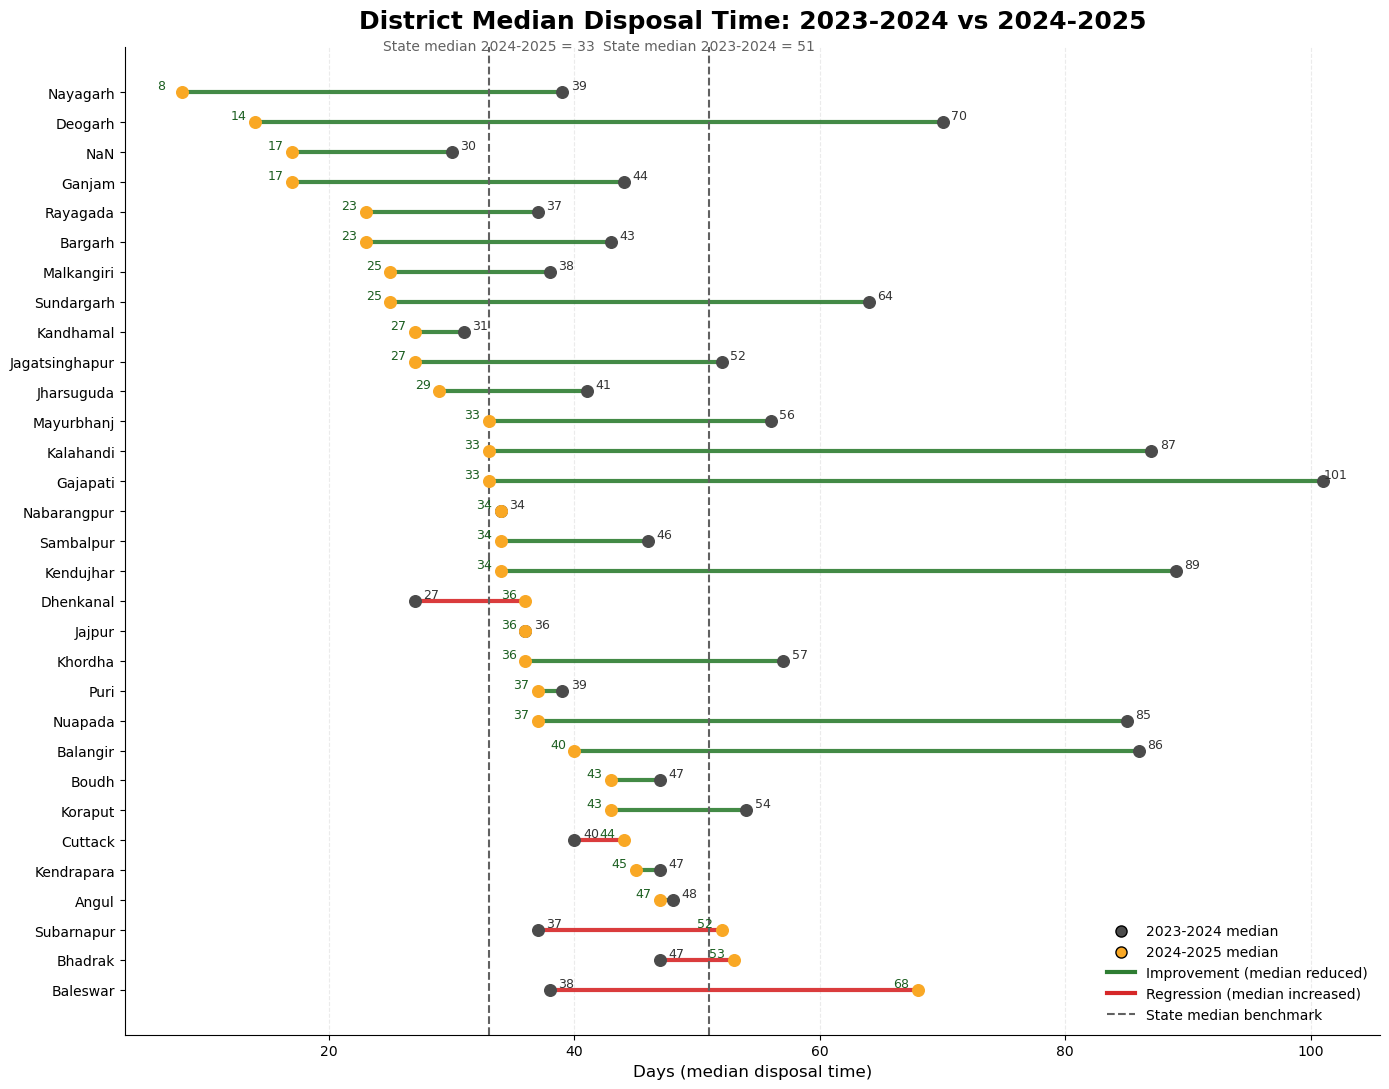

In [30]:
from matplotlib.lines import Line2D

COL_EARLY, COL_LATE = "#4b4b4b", "#f9a825"
COL_IMPROVE, COL_REGRESS = "#2e7d32", "#d62728"
COL_STATE = "#616161"

y = np.arange(len(wide))
fig, ax = plt.subplots(figsize=(14, 11))

for i, r in wide.iterrows():
    x0, x1 = r["median_early"], r["median_late"]
    ax.plot([x0, x1], [i, i], lw=3, solid_capstyle="round", alpha=0.9,
            color=COL_IMPROVE if x1 <= x0 else COL_REGRESS)

ax.scatter(wide["median_early"], y, s=70, color=COL_EARLY, zorder=3)
ax.scatter(wide["median_late"], y, s=70, color=COL_LATE, zorder=3)

for i, r in wide.iterrows():
    ax.text(r["median_early"] + 2, i, f"{int(r['median_early'])}",
            va="bottom", ha="right", fontsize=9, color="#333333")
    ax.text(r["median_late"] - 2, i, f"{int(r['median_late'])}",
            va="bottom", ha="left", fontsize=9, color="#1b5e20")

ax.set_yticks(y)
ax.set_yticklabels(wide["district"], fontsize=10)
ax.invert_yaxis()

ax.axvline(state_median_early, ls="--", lw=1.5, color=COL_STATE)
ax.axvline(state_median_late, ls="--", lw=1.5, color=COL_STATE)
ax.text(state_median_early, -1.3,
        f"State median {MAP_YEARS[0]} = {int(state_median_early)}",
        ha="center", va="bottom", fontsize=10, color=COL_STATE)
ax.text(state_median_late, -1.3,
        f"State median {MAP_YEARS[1]} = {int(state_median_late)}",
        ha="center", va="bottom", fontsize=10, color=COL_STATE)

ax.set_title("District Median Disposal Time: "
             f"{MAP_YEARS[0]} vs {MAP_YEARS[1]}",
             fontsize=18, weight="bold", pad=14)
ax.set_xlabel("Days (median disposal time)", fontsize=12)
ax.grid(True, axis="x", linestyle="--", alpha=0.25)
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)

ax.legend(handles=[
    Line2D([0], [0], marker="o", color="none", markerfacecolor=COL_EARLY,
           markersize=8, label=f"{MAP_YEARS[0]} median"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor=COL_LATE,
           markersize=8, label=f"{MAP_YEARS[1]} median"),
    Line2D([0], [0], color=COL_IMPROVE, lw=3,
           label="Improvement (median reduced)"),
    Line2D([0], [0], color=COL_REGRESS, lw=3,
           label="Regression (median increased)"),
    Line2D([0], [0], color=COL_STATE, lw=1.5, ls="--",
           label="State median benchmark"),
], loc="lower right", frameon=False)

plt.tight_layout()
plt.show()

## District Choropleth: Resolution Time

District map of focus-year median resolution time, and its deviation from
the state median (diverging scale centered at zero).

In [31]:
gdf = load_district_shapefile()

# Focus-year median per district.
district_median_focus = (
    df_res[df_res["custom_year"] == FOCUS_YEAR]
    .groupby("district")["disposal_days"].median()
    .round(0).reset_index(name="median_focus")
)
district_median_focus["district_clean"] = (
    district_median_focus["district"].str.strip().str.upper()
)

state_median_focus = float(np.round(
    df_res.loc[df_res["custom_year"] == FOCUS_YEAR, "disposal_days"]
          .median(), 0))
district_median_focus["diff_from_state"] = (
    district_median_focus["median_focus"] - state_median_focus
)

map_df = gdf.merge(district_median_focus, on="district_clean", how="left")

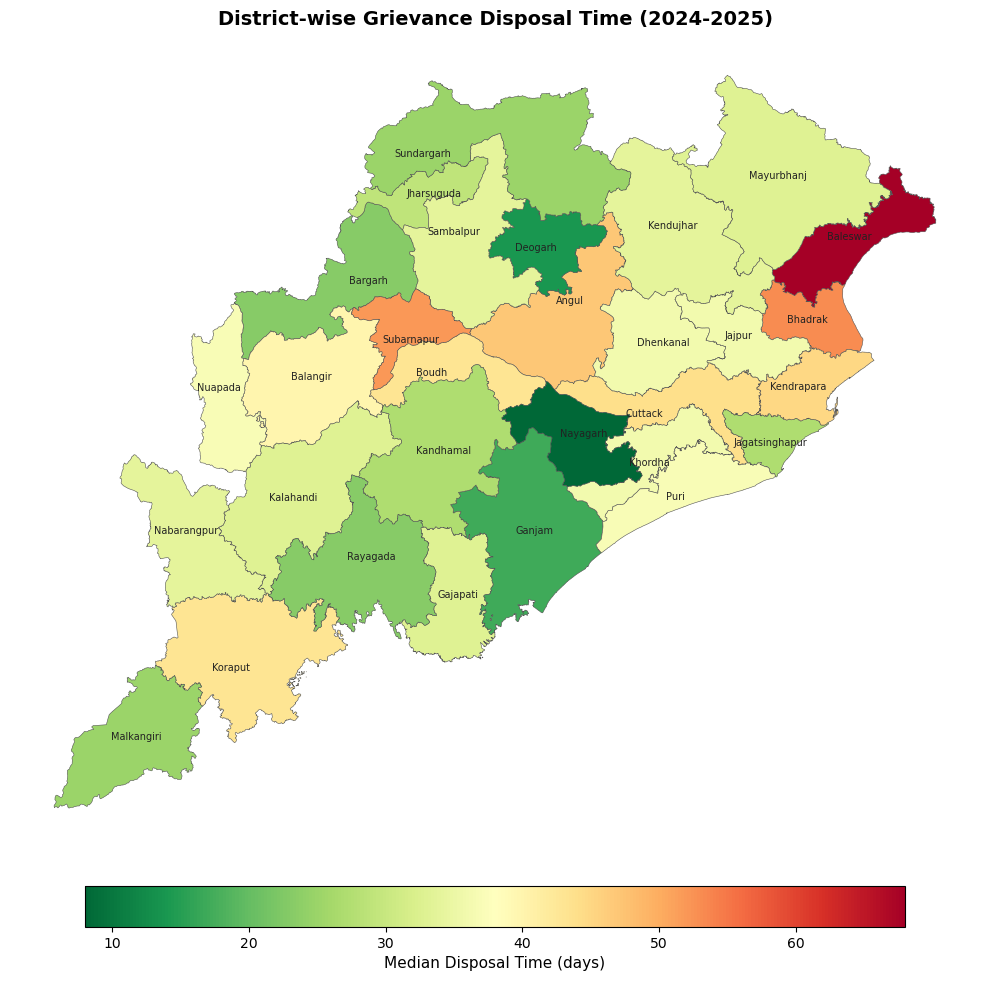

In [32]:
plot_disposal_map(
    map_df, "median_focus",
    title=f"District-wise Grievance Disposal Time ({FOCUS_YEAR})",
    cbar_label="Median Disposal Time (days)",
)

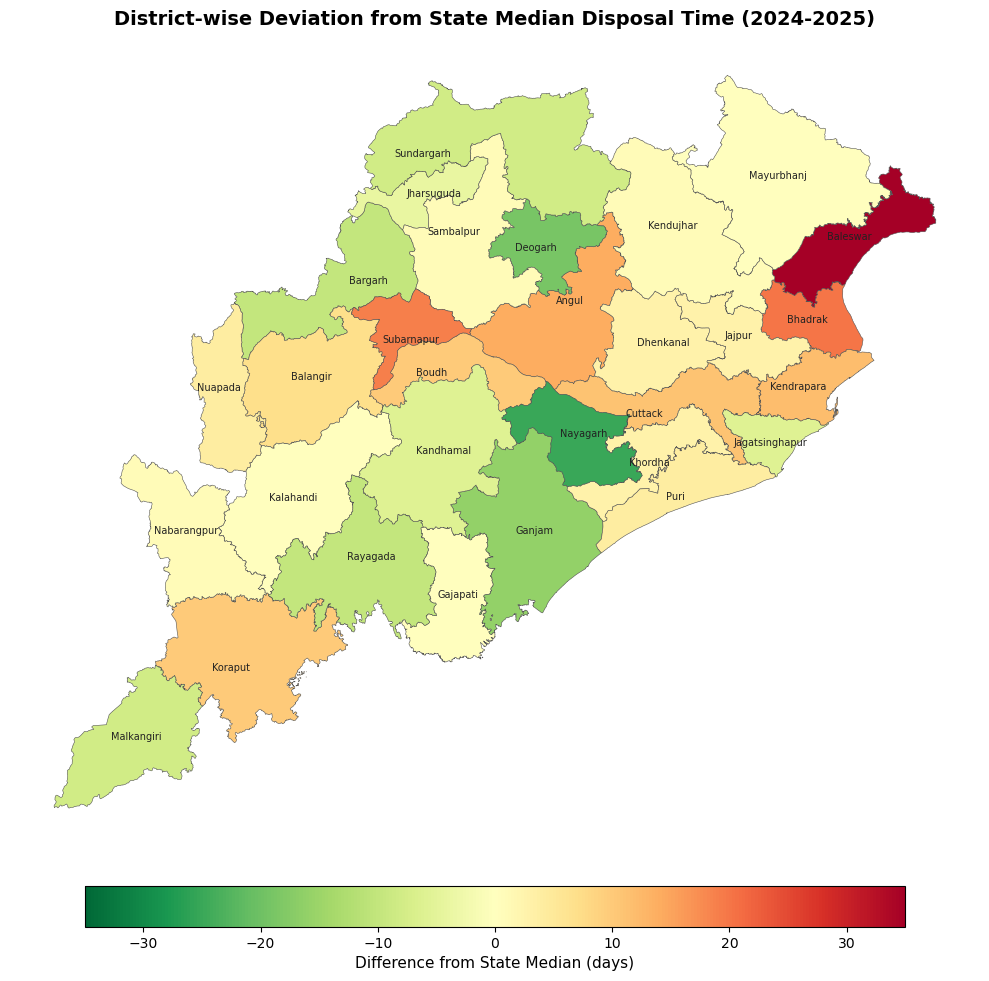

In [33]:
plot_disposal_map(
    map_df, "diff_from_state",
    title=("District-wise Deviation from State Median "
           f"Disposal Time ({FOCUS_YEAR})"),
    cbar_label="Difference from State Median (days)",
    diverging=True,
)

## Petitioner-level Disposal Stats

In [34]:
pet_disposal = build_petitioner_disposal(df_res)
 
print("Petitioner-level Disposal — Overall:")
print(pet_disposal["avg_disposal"]
      .agg(["count", "mean", "median", "std"]).round(2))

Petitioner-level Disposal — Overall:
count     839052.00
mean          84.69
median        44.17
std          113.62
Name: avg_disposal, dtype: float64


In [35]:
print("\nPetitioner-level Disposal — Yearly:")
print(petitioner_disposal_yearly(pet_disposal))


Petitioner-level Disposal — Yearly:
  custom_year  petitioners    mean  median     std
0   2021-2022        64343  204.65  149.70  204.92
1   2022-2023       115754   89.48   40.14  138.29
2   2023-2024       250419   97.81   56.77  111.60
3   2024-2025       408536   56.40   34.81   60.55
4   Aggregate       839052   84.69   44.17  113.62


In [36]:
print("\nPetitioner-level Disposal — District:")
print(petitioner_disposal_summary(pet_disposal, "district"))


Petitioner-level Disposal — District:
          district  petitioners    mean  median     std
0           Ganjam        65364   59.60   27.03   92.57
1        Kalahandi        57100   98.40   56.11  116.56
2         Balangir        49987   90.59   53.30  106.21
3         Baleswar        46415  120.06   76.22  138.95
4          Khordha        42242  104.65   50.98  146.61
5       Mayurbhanj        39178   88.45   41.87  128.45
6          Bhadrak        38472   94.13   60.78  109.93
7          Cuttack        37817   91.38   50.21  124.92
8           Jajpur        37500   76.87   38.98  113.22
9        Dhenkanal        36243   62.92   32.68   83.35
10       Sambalpur        32999   68.91   37.84   89.75
11      Sundargarh        32019   73.45   44.46   91.46
12            Puri        29675   81.28   43.92  105.32
13         Bargarh        29225   61.99   28.33   91.46
14       Kendujhar        28532   84.44   51.10  104.72
15  Jagatsinghapur        26524   86.46   45.38  113.50
16      K

In [37]:
print("\nPetitioner-level Disposal — Category:")
print(petitioner_disposal_summary(pet_disposal, "category"))


Petitioner-level Disposal — Category:
                       category  petitioners    mean  median     std
0                       Housing       253881   78.57   53.57   78.88
1                Social Welfare       157384   59.84   36.02   70.48
2                           NaN       103516   80.21    7.92  153.52
3                       General        72581  110.26   53.92  145.19
4                Infrastructure        51807   97.79   42.16  126.01
5                 Miscellaneous        41962  101.36   54.22  127.94
6                  Land Matters        32328   84.91   47.99  104.23
7               Service Matters        26575  113.15   63.23  142.80
8                   Police Case        25515   86.55   49.87  109.25
9          Financial Assistance        13427   94.82   38.11  136.17
10                       Energy         8042   99.29   53.28  125.07
11               Public Utility         7464  120.43   56.74  152.43
12                    Education         7183  112.63   54.94  15

In [38]:
print("\nPetitioner-level Disposal — Subcategory (top 10):")
print(petitioner_disposal_summary(pet_disposal, "subcategory").head(10))


Petitioner-level Disposal — Subcategory (top 10):
                     subcategory  petitioners    mean  median     std
0                  Rural Housing       252092   78.54   53.67   78.71
1              IAY/MKY/BPGY/PMAY       107009   54.85   35.27   57.58
2                            NaN        87313   31.08    3.78   68.82
3                         Others        64312  111.83   54.70  146.63
4           Miscellaneous/Others        32816   97.64   50.96  124.34
5                   Police Cases        18614   82.60   47.14  106.29
6                 Excise Matters        16869  334.99  295.69  207.18
7          Religious Institution        15066   68.84   29.93  100.25
8  Land Allotment/Settlement/RoR        14933   81.60   46.08  100.84
9                Service Matters        13099  116.16   63.19  150.24


In [39]:
print("\nPetitioner-level Disposal — Office:")
print(petitioner_disposal_summary(pet_disposal, "office"))


Petitioner-level Disposal — Office:
                     office  petitioners    mean  median     std
0                 Collector       532674   71.56   37.07   97.11
1               Departments       130530  104.31   67.78  118.95
2  Office of Chief Minister       128558  108.53   55.98  142.81
3  Superintendent of Police        18962   98.79   42.85  147.96
4                       NaN        10696  138.03   84.22  162.46
5           Chief Secretary         7310  124.02   66.10  166.00
6            DG & IG Police         7101   92.06   54.86  107.92
7                  Governor         3221  142.97   98.89  163.16
8                     TOTAL       912207   84.69   44.17  113.62


In [40]:
print("\nPetitioner-level Disposal — Department:")
print(petitioner_disposal_summary(pet_disposal, "dept"))


Petitioner-level Disposal — Department:
                                                 dept  petitioners    mean  \
0                     Panchayati Raj & Drinking Water       400468   76.77   
1                                                 NaN       100713   75.41   
2                       Revenue & Disaster Management        52857   85.06   
3           General Administration & Public Grievance        52574   91.23   
4                                     Home department        39482   98.82   
5                         Housing & Urban Development        28729  108.92   
6   Social Security & Empowerment of Persons with ...        24632   70.84   
7                             School & Mass Education        19548  140.64   
8                    Food Supplies & Consumer Welfare        17773   82.03   
9                             Health & Family Welfare        14808  118.91   
10                 Agriculture & Farmers' Empowerment        11852   82.68   
11                     